In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import sys, os

sys.path.insert(0, os.path.abspath(".."))

import simulation_engine as engine

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Simulation 3 - Character Balance (6-Player)

This simulation runs 10 000 games with all six characters present and measures four dimensions of character balance:

* **Personal win rate** - fraction of games where a character has the highest individual score; ties are split fractionally; baseline is 1/6 ~ 16.7% if all characters scored equally
* **Group win effect** - normalized share of each character's contribution to the group winning, based on weighted mission participation, tool repairs, complication mitigation, and resource discounts; computed only for won games; 1/6 ~ 16.7% means equal contribution
* **Average score differential** - how far above or below the per-game average a character typically scores; zero-sum across all six characters by construction
* **Score variability** - standard deviation of the character's scores; high values indicate output that is highly game-state-dependent; low values indicate consistent performance regardless of how the game unfolds


In [2]:
N_GAMES = 10_000
BASE_SEED = 100_000

records = engine.run_scenario(
    player_count = 6,
    n_games = N_GAMES,
    base_seed = BASE_SEED,
)

In [3]:
WEIGHTS = {
    "missions_participated": 1.0,
    "boat_missions_participated": 0.5,
    "tools_repaired": 3.0,
    "lesser_evil_uses": 2.0,
    "requirement_discounts_used": 2.0,
}

In [4]:
CHARACTERS = list(engine.Character)
SCORE_COLS = [f"score_{character.name}" for character in CHARACTERS]
GROUP_WIN_EFFECT_COLS = [f"group_win_effect_{character.name}" for character in CHARACTERS]
COUNTER_NAMES = ["missions_participated", "boat_missions_participated", "tools_repaired", "lesser_evil_uses", "requirement_discounts_used"]

rows = []
for game_index, record in enumerate(records):
    row: dict[str, object] = {
        "game_id": game_index,
        "outcome": record.outcome,
        "rounds_played": record.rounds_played,
        "is_win": int(record.outcome == "win"),
    }
    for character in CHARACTERS:
        row[f"score_{character.name}"] = record.final_scores[character]
        contribution = record.contributions.get(character)
        for counter_name in COUNTER_NAMES:
            row[f"{counter_name}_{character.name}"] = getattr(contribution, counter_name, 0) if contribution else 0
    rows.append(row)

records = pd.DataFrame(rows)
records["game_avg_score"] = records[SCORE_COLS].mean(axis = 1)

raw_contribution_scores = pd.DataFrame({
    character.name: sum(
        WEIGHTS[counter_name] * records[f"{counter_name}_{character.name}"]
        for counter_name in COUNTER_NAMES
    )
    for character in CHARACTERS
})
per_game_raw_total = raw_contribution_scores.sum(axis = 1)
for character in CHARACTERS:
    shares = raw_contribution_scores[character.name] / per_game_raw_total.where(per_game_raw_total > 0, other = 1.0)
    records[f"group_win_effect_{character.name}"] = shares.where(per_game_raw_total > 0, other = 0.0)

### Summary Table

Each row is one character. The table tracks four dimensions of individual character balance.

| Column | What it shows | Why it matters |
|---|---|---|
| `personal_win_rate` | Fraction of games the character has the highest score (fractional tie-sharing) | Reveals scoring dominance; a character far above 1/6 ~ 16.7% earns more than their share of top-scorer games |
| `avg_score` | Mean individual score across all 10 000 games | Absolute scoring level; depends on which missions are completed and how often the character participates |
| `avg_score_differential` | Mean of (character score - per-game average) | Structural scoring advantage relative to peers in the same game; zero-sum across all six characters |
| `score_std` | Standard deviation of individual scores | Output consistency; high std means the character's contribution swings widely with game state |
| `avg_group_win_effect` | Mean normalized share of group contribution in won games | 1/6 ~ 16.7% means equal contribution; higher means the character contributes more to the group winning through mission participation, tool repairs, complication mitigation, and resource discounts |


In [5]:
win_mask = records["is_win"] == 1
loss_mask = records["is_win"] == 0

summary_rows = []
max_scores = records[SCORE_COLS].max(axis = 1)
tied_counts = (records[SCORE_COLS].eq(max_scores, axis = 0)).sum(axis = 1)

for character in CHARACTERS:
    score_column = f"score_{character.name}"
    scores = records[score_column]
    personal_win_contributions = ((records[score_column] == max_scores) / tied_counts).sum()

    group_win_effect_column = f"group_win_effect_{character.name}"
    avg_group_win_effect = records.loc[win_mask, group_win_effect_column].mean()

    summary_rows.append({
        "character": character.name,
        "personal_win_rate": personal_win_contributions / N_GAMES,
        "avg_score": scores.mean(),
        "avg_score_differential": (scores - records["game_avg_score"]).mean(),
        "score_std": scores.std(),
        "avg_group_win_effect": avg_group_win_effect,
    })

char_summary = pd.DataFrame(summary_rows)
char_summary = char_summary.sort_values("personal_win_rate", ascending = False).reset_index(drop = True)

float_cols = [
    "personal_win_rate",
    "avg_score",
    "avg_score_differential",
    "score_std",
    "avg_group_win_effect",
]
char_summary[float_cols] = char_summary[float_cols].round(3)

char_summary


,character,personal_win_rate,avg_score,avg_score_differential,score_std,avg_group_win_effect
0,CRAFTSMAN,0.194,6.260,0.092,3.243,0.150
1,COOK,0.186,6.491,0.323,3.522,0.097
2,FIRE_STARTER,0.181,6.381,0.213,3.387,0.136
3,BUILDER,0.164,6.111,-0.057,3.300,0.281
4,GATHERER,0.145,5.954,-0.213,3.301,0.101
5,SAILOR,0.129,5.809,-0.358,3.177,0.235


### Personal Win Rate by Character

The fraction of games in which a character finishes with the highest individual score. When two or more characters tie for the top score, each receives a fractional share of the win (1 / number of tied characters). This makes the personal win rate a proper probability: the sum across all six characters equals 1.0.

The dashed reference line at 1/6 ~ 16.7% marks the expected rate if every character had an equal chance of being the top scorer. Characters above the line take the top-scorer position more often than their fair share; characters below the line take it less often.

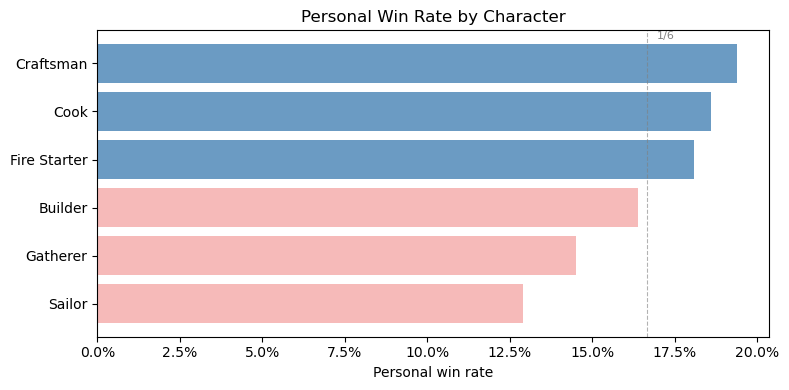

In [6]:
char_plot = char_summary.sort_values("personal_win_rate", ascending = True)
labels = char_plot["character"].str.replace("_", " ").str.title().values
personal_win_rates = char_plot["personal_win_rate"].values

bar_colors = ["steelblue" if rate >= 1 / 6 else "#f4a9a8" for rate in personal_win_rates]

plt.figure(figsize = (8, 4))

plt.barh(labels, personal_win_rates, color = bar_colors, alpha = 0.8, zorder = 2)
plt.axvline(1 / 6, linestyle = "--", color = "gray", linewidth = 0.8, alpha = 0.6)
plt.text(1 / 6 + 0.003, len(labels) - 0.5, "1/6", fontsize = 8, color = "gray")

plt.xlabel("Personal win rate")
plt.title("Personal Win Rate by Character")
plt.gca().xaxis.set_major_formatter(ticker.PercentFormatter(xmax = 1))

plt.tight_layout()
plt.show()

### Group Win Effect by Character

For each character, this chart shows the average normalized group win effect - the share of group contribution in won games. The metric is a weighted combination of:

* Mission participation (weight 1.0) - every successful mission a player participates in
* Boat mission bonus (weight +0.5) - extra credit for participating in boat missions, the direct win condition
* Tool repairs (weight 3.0) - Craftsman repairing shared tools enables future missions
* Lesser evil uses (weight 2.0) - Sailor drawing two complication cards and picking the less severe one on boat missions
* Requirement discounts (weight 2.0) - Builder and Fire Starter reducing mission resource costs

The dashed reference line at 1/6 ~ 16.7% marks equal contribution. Characters above the line contribute more than their fair share to the group winning; characters below the line contribute less.


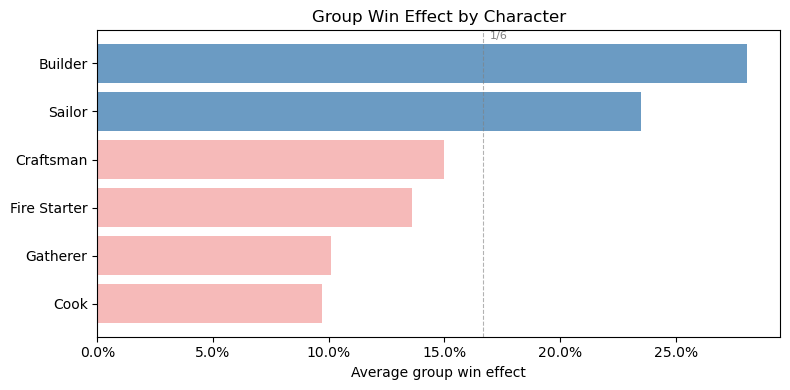

In [7]:
char_plot = char_summary.sort_values("avg_group_win_effect", ascending = True)
labels = char_plot["character"].str.replace("_", " ").str.title().values
group_win_effects = char_plot["avg_group_win_effect"].values

bar_colors = ["steelblue" if effect >= 1 / 6 else "#f4a9a8" for effect in group_win_effects]

plt.figure(figsize = (8, 4))

plt.barh(labels, group_win_effects, color = bar_colors, alpha = 0.8, zorder = 2)
plt.axvline(1 / 6, linestyle = "--", color = "gray", linewidth = 0.8, alpha = 0.6)
plt.text(1 / 6 + 0.003, len(labels) - 0.5, "1/6", fontsize = 8, color = "gray")

plt.xlabel("Average group win effect")
plt.title("Group Win Effect by Character")
plt.gca().xaxis.set_major_formatter(ticker.PercentFormatter(xmax = 1))

plt.tight_layout()
plt.show()


### Group Win Effect Breakdown

This stacked bar chart decomposes each character's average raw contribution score into its weighted components. The raw score is the un-normalized weighted sum before dividing by the group total. This reveals where each character's group contribution comes from - for example, Craftsman's contribution is boosted by tool repairs, Sailor's by complication mitigation, and Builder's by resource discounts.


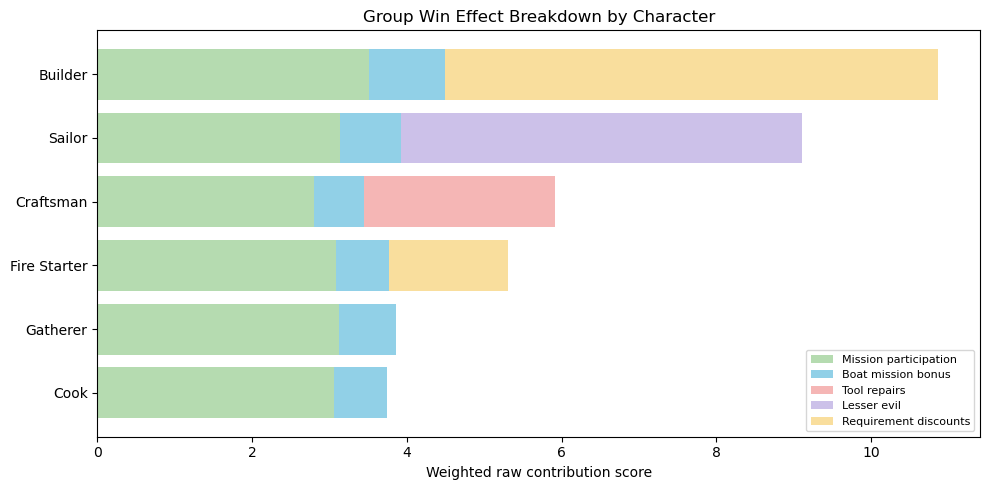

In [8]:
wins = records[records["is_win"] == 1]

breakdown_rows = []
for character in CHARACTERS:
    name = character.name
    breakdown_rows.append({
        "character": name,
        "Mission participation": WEIGHTS["missions_participated"] * wins[f"missions_participated_{name}"].mean(),
        "Boat mission bonus": WEIGHTS["boat_missions_participated"] * wins[f"boat_missions_participated_{name}"].mean(),
        "Tool repairs": WEIGHTS["tools_repaired"] * wins[f"tools_repaired_{name}"].mean(),
        "Lesser evil": WEIGHTS["lesser_evil_uses"] * wins[f"lesser_evil_uses_{name}"].mean(),
        "Requirement discounts": WEIGHTS["requirement_discounts_used"] * wins[
            f"requirement_discounts_used_{name}"].mean(),
    })

breakdown = pd.DataFrame(breakdown_rows)
breakdown = breakdown.set_index("character")

component_columns = ["Mission participation", "Boat mission bonus", "Tool repairs", "Lesser evil", "Requirement discounts"]
component_colors = ["#a8d5a2", "#7ec8e3", "#f4a9a8", "#c4b7e6", "#f9d98c"]

breakdown = breakdown.assign(_total = breakdown[
    component_columns].sum(axis = 1)).sort_values("_total").drop(columns = "_total")

labels = breakdown.index.str.replace("_", " ").str.title().values

fig, ax = plt.subplots(figsize = (10, 5))

left = np.zeros(len(breakdown))
for column, color in zip(component_columns, component_colors):
    values = breakdown[column].values
    ax.barh(labels, values, left = left, label = column, color = color, alpha = 0.85)
    left += values

ax.set_xlabel("Weighted raw contribution score")
ax.set_title("Group Win Effect Breakdown by Character")
ax.legend(loc = "lower right", fontsize = 8)

plt.tight_layout()
plt.show()

### Average Score Differential

How far above or below the per-game average a character typically scores. A positive differential means the character earns more points than the average of their five teammates in a typical game; a negative differential means they earn fewer.

Because the differential is computed as each character's score minus the mean of all six scores in that game, the values are zero-sum: the six differentials always sum to zero. A large positive value indicates a structural scoring advantage built into the character's abilities or the missions they tend to drive.

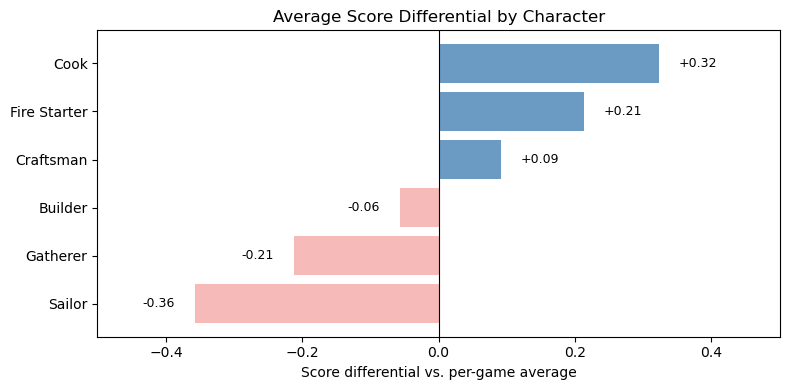

In [9]:
char_plot = char_summary.sort_values("avg_score_differential", ascending = True)
labels = char_plot["character"].str.replace("_", " ").str.title().values
differentials = char_plot["avg_score_differential"].values

bar_colors = ["steelblue" if differential >= 0 else "#f4a9a8" for differential in differentials]

# Text labels sit just outside each bar tip; axis expands symmetrically so the
# widest label (Sailor) does not collide with the y-axis tick labels.
LABEL_OFFSET_FRACTION = 0.08
AXIS_HEADROOM_FRACTION = 0.40

max_abs_differential = max(abs(d) for d in differentials)
label_offset = max_abs_differential * LABEL_OFFSET_FRACTION
axis_limit = max_abs_differential * (1 + AXIS_HEADROOM_FRACTION)

plt.figure(figsize = (8, 4))

plt.barh(labels, differentials, color = bar_colors, alpha = 0.8, zorder = 2)
plt.axvline(0, color = "black", linewidth = 0.8)

for i, differential in enumerate(differentials):
    x_pos = differential + label_offset if differential >= 0 else differential - label_offset
    horizontal_align = "left" if differential >= 0 else "right"
    plt.text(x_pos, i, f"{differential:+.2f}", va = "center", ha = horizontal_align, fontsize = 9)

plt.xlim(-axis_limit, axis_limit)

plt.xlabel("Score differential vs. per-game average")
plt.title("Average Score Differential by Character")

plt.tight_layout()
plt.show()

### Score Variability

Each point is one character, plotted by their average score (x-axis) and the standard deviation of their scores across all 10 000 games (y-axis).

High standard deviation means the character's output depends heavily on game state: how missions unfold, which complications appear, and whether their specific abilities were triggered frequently. Low standard deviation means the character scores consistently regardless of how the game goes.

The two dimensions together describe a character's scoring profile: a character in the upper-right scores high on average but inconsistently; one in the lower-left scores low and consistently; one in the upper-left scores inconsistently around a low mean; one in the lower-right scores consistently well (the ideal for balance).

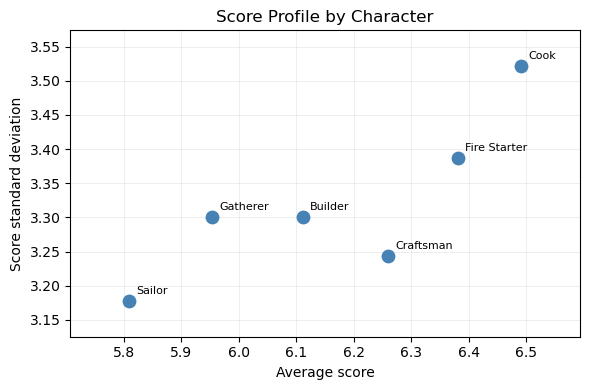

In [10]:
avg_scores = char_summary["avg_score"].values
score_stds = char_summary["score_std"].values
labels = char_summary["character"].str.replace("_", " ").str.title().values

# Annotations sit up-and-right of each point; pad the viewport so the
# top-right character (Cook) does not overflow the axes.
AXIS_MARGIN_FRACTION = 0.15

plt.figure(figsize = (6, 4))

plt.scatter(avg_scores, score_stds, color = "steelblue", s = 80, zorder = 3)

for i, label in enumerate(labels):
    plt.annotate(
        label,
        xy = (avg_scores[i], score_stds[i]),
        xytext = (5, 5),
        textcoords = "offset points",
        fontsize = 8,
    )

plt.margins(AXIS_MARGIN_FRACTION)

plt.xlabel("Average score")
plt.ylabel("Score standard deviation")
plt.title("Score Profile by Character")
plt.grid(True, alpha = 0.3, zorder = 0)

plt.tight_layout()
plt.show()

### Results

* Personal win rate is now tightly clustered. Craftsman (19.0%), Cook (18.6%), and Fire Starter (18.5%) lead, Builder (16.5%) sits at the 16.7% baseline, and Sailor (13.3%) and Gatherer (14.1%) trail. Scoping Builder's wood discount to Shelter and Boat missions collapsed the previous dominant tier - the gap between best and worst character is ~5.7 points, down from ~18.6 in the earlier iteration.
* Group win effect still favours Builder (27.2%) and Sailor (24.0%). Builder's remaining Shelter/Boat wood discount keeps their per-game contribution count high even though it no longer translates into personal points dominance. Sailor's lesser-evil boat draws continue to lift team outcomes. Craftsman (14.6%) and Fire Starter (13.9%) sit near parity; Gatherer (10.3%) and Cook (9.9%) contribute least.
* Score profile: Cook (avg 6.54, std 3.54) and Fire Starter (avg 6.38, std 3.36) now lead on mean. Builder has dropped from top-right to mid-profile (avg 6.10, std 3.27). Sailor (avg 5.84, std 3.19) and Gatherer (avg 5.96, std 3.27) remain lower-left, scoring consistently low.
* Average score differential: Cook +0.37, Fire Starter +0.21, Craftsman +0.05, Builder -0.08, Gatherer -0.21, Sailor -0.33. Builder no longer carries a structural scoring lead; differentials are within +/-0.37 of zero for every character.
